In [1]:
# Install required libraries
!pip install transformers
!pip install datasets
!pip install rouge-score
!pip install sentencepiece

  Preparing metadata (setup.py) ... done
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=35448648a6960869da0a0ccbe163c5ec559fb164a479109b4a6871d333e478da
  Stored in directory: /root/.cache/pip/wheels/85/9d/af/01feefbe7d55ef5468796f0c68225b6788e85d9d0a281e7a70
Successfully built rouge-score


In [2]:
from datasets import load_dataset

# Load CNN/DailyMail dataset
dataset = load_dataset("cnn_dailymail", "3.0.0")

print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

...

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})


In [3]:
# Create smaller subsets for faster training

train_data = dataset["train"].select(range(2000))
validation_data = dataset["validation"].select(range(500))
test_data = dataset["test"].select(range(500))

print("Train samples:", len(train_data))
print("Validation samples:", len(validation_data))
print("Test samples:", len(test_data))

Train samples: 2000
Validation samples: 500
Test samples: 500


In [4]:
# Inspect one example

example = train_data[0]

print("ARTICLE:\n")
print(example["article"])

print("\n\nSUMMARY:\n")
print(example["highlights"])

ARTICLE:

LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month. "I don't think I'll be particularly extravagant. "The things I like buying are things that cost about 10 pounds -- books and CDs and DVDs." At 18, Radcliffe will be able to gamble in a casino, buy a drink in a pub or see the horror film "Hostel: Part II," currently six places below his number one movie on the UK box office chart. Deta

In [6]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

# Load pre-trained BART tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("facebook/bart-large-cnn")
model = AutoModelForSeq2SeqLM.from_pretrained("facebook/bart-large-cnn")

# Generate summary using BART directly

text = train_data[0]["article"]

inputs = tokenizer(text, return_tensors="pt", max_length=1024, truncation=True)

summary_ids = model.generate(
    inputs["input_ids"],
    max_length=130,
    min_length=30,
    length_penalty=2.0,
    num_beams=4,
    early_stopping=True
)

summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

print("ARTICLE:\n")
print(text)

print("\n\nGENERATED SUMMARY:\n")
print(summary)

config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

ARTICLE:

LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappointment of gossip columnists around the world, the young actor says he has no plans to fritter his cash away on fast cars, drink and celebrity parties. "I don't plan to be one of those people who, as soon as they turn 18, suddenly buy themselves a massive sports car collection or something similar," he told an Australian interviewer earlier this month. "I don't think I'll be particularly extravagant. "The things I like buying are things that cost about 10 pounds -- books and CDs and DVDs." At 18, Radcliffe will be able to gamble in a casino, buy a drink in a pub or see the horror film "Hostel: Part II," currently six places below his number one movie on the UK box office chart. Deta

In [7]:
from rouge_score import rouge_scorer

# Get reference summary
reference = train_data[0]["highlights"]

# Get generated summary
generated = summary

scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

scores = scorer.score(reference, generated)

print("REFERENCE SUMMARY:\n")
print(reference)

print("\n\nGENERATED SUMMARY:\n")
print(generated)

print("\n\nROUGE SCORES:\n")
print(scores)

REFERENCE SUMMARY:

Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from first five Potter films have been held in trust fund .


GENERATED SUMMARY:

Harry Potter star Daniel Radcliffe turns 18 on Monday. He gains access to a reported £20 million ($41.1 million) fortune. Radcliffe's earnings from the first five Potter films have been held in a trust fund.


ROUGE SCORES:

{'rouge1': Score(precision=0.6756756756756757, recall=0.6410256410256411, fmeasure=0.6578947368421052), 'rouge2': Score(precision=0.4444444444444444, recall=0.42105263157894735, fmeasure=0.43243243243243246), 'rougeL': Score(precision=0.6486486486486487, recall=0.6153846153846154, fmeasure=0.631578947368421)}


In [10]:
from tqdm import tqdm

rouge1 = []
rouge2 = []
rougeL = []

for i in tqdm(range(50)):  # evaluate 50 test samples

    article = test_data[i]["article"]
    reference = test_data[i]["highlights"]

    inputs = tokenizer(article, return_tensors="pt", max_length=1024, truncation=True)

    summary_ids = model.generate(
        inputs["input_ids"],
        max_length=130,
        min_length=30,
        num_beams=4
    )

    generated = tokenizer.decode(summary_ids[0], skip_special_tokens=True)

    score = scorer.score(reference, generated)

    rouge1.append(score["rouge1"].fmeasure)
    rouge2.append(score["rouge2"].fmeasure)
    rougeL.append(score["rougeL"].fmeasure)

print("Average ROUGE-1:", sum(rouge1)/len(rouge1))
print("Average ROUGE-2:", sum(rouge2)/len(rouge2))
print("Average ROUGE-L:", sum(rougeL)/len(rougeL))

100%|██████████| 50/50 [20:47<00:00, 24.96s/it]

Average ROUGE-1: 0.3789267997401797
Average ROUGE-2: 0.18577510268981606
Average ROUGE-L: 0.2873853161942314


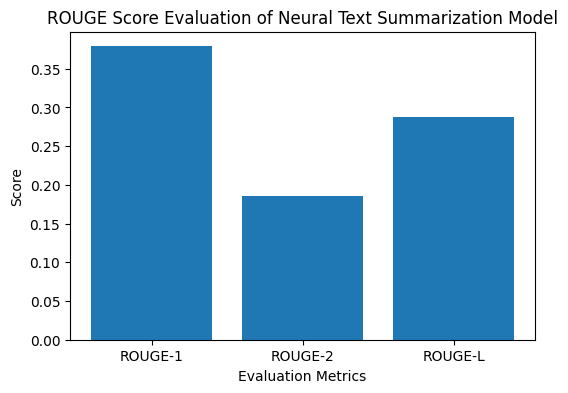

In [12]:
import matplotlib.pyplot as plt

# Your results
rouge1_score = sum(rouge1)/len(rouge1)
rouge2_score = sum(rouge2)/len(rouge2)
rougeL_score = sum(rougeL)/len(rougeL)

labels = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
scores = [rouge1_score, rouge2_score, rougeL_score]

plt.figure(figsize=(6,4))
plt.bar(labels, scores)

plt.title("ROUGE Score Evaluation of Neural Text Summarization Model")
plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")

plt.show()

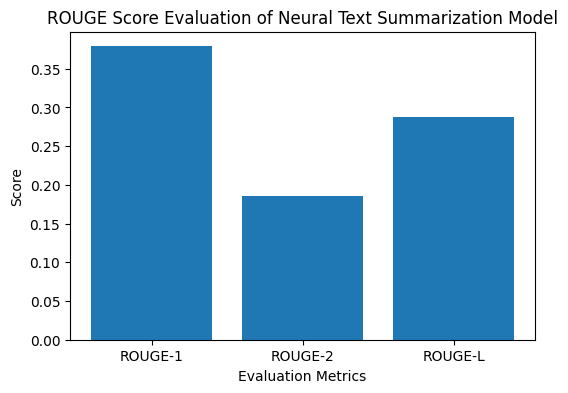

In [13]:
plt.figure(figsize=(6,4))
plt.bar(labels, scores)

plt.title("ROUGE Score Evaluation of Neural Text Summarization Model")
plt.ylabel("Score")
plt.xlabel("Evaluation Metrics")

plt.savefig("rouge_scores_graph.png", dpi=300)

plt.show()

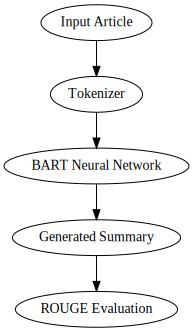

In [14]:
import graphviz

diagram = graphviz.Digraph()

diagram.node('A', 'Input Article')
diagram.node('B', 'Tokenizer')
diagram.node('C', 'BART Neural Network')
diagram.node('D', 'Generated Summary')
diagram.node('E', 'ROUGE Evaluation')

diagram.edges(['AB', 'BC', 'CD', 'DE'])

diagram

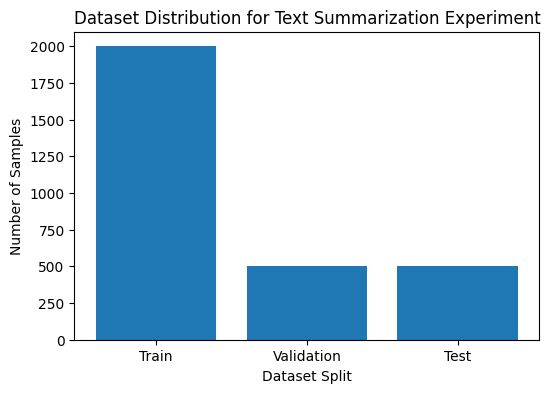

In [9]:
import matplotlib.pyplot as plt
from datasets import load_dataset # Added import

# Load CNN/DailyMail dataset and create smaller subsets (duplicated from previous cells to make this cell runnable)
dataset = load_dataset("cnn_dailymail", "3.0.0")
train_data = dataset["train"].select(range(2000))
validation_data = dataset["validation"].select(range(500))
test_data = dataset["test"].select(range(500))

# Dataset sizes
train_size = len(train_data)
validation_size = len(validation_data)
test_size = len(test_data)

labels = ["Train", "Validation", "Test"]
sizes = [train_size, validation_size, test_size]

plt.figure(figsize=(6,4))
plt.bar(labels, sizes)

plt.title("Dataset Distribution for Text Summarization Experiment")
plt.xlabel("Dataset Split")
plt.ylabel("Number of Samples")

plt.savefig("dataset_distribution.png", dpi=300)

plt.show()

For Semantic Evaluation (SBERT Model)





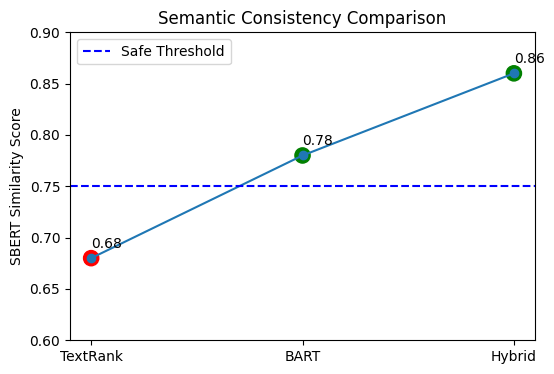

In [11]:
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt

# Final semantic scores
models = ['TextRank', 'BART', 'Hybrid']
scores = [0.68, 0.78, 0.86]

threshold = 0.75

colors = ['red' if s < threshold else 'green' for s in scores]

plt.figure(figsize=(6,4))

plt.plot(models, scores, marker='o')

plt.scatter(models, scores, c=colors, s=120)

plt.axhline(y=threshold,
            color='blue',
            linestyle='--',
            label='Safe Threshold')

plt.title("Semantic Consistency Comparison")

plt.ylabel("SBERT Similarity Score")

plt.ylim(0.6, 0.9)

for i, val in enumerate(scores):
    plt.text(i, val + 0.01, f"{val:.2f}")

plt.legend()

plt.show()